In [1]:
library(tidyverse)
library(reshape2)
library(lubridate)
library(ggpubr)
library(patchwork)


source("../theme_ggplot_cfrna.R")
source("../functions.R")
gene_key = read.delim("../gencode.biotype.name.key.tsv")

── Attaching packages ─────────────────────────────────────── tidyverse 1.3.1 ──

✔ ggplot2 3.5.1     ✔ purrr   1.0.2
✔ tibble  3.2.1     ✔ dplyr   1.1.4
✔ tidyr   1.3.1     ✔ stringr 1.5.1
✔ readr   2.1.2     ✔ forcats 0.5.1

── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()


Attaching package: ‘reshape2’


The following object is masked from ‘package:tidyr’:

    smiths



Attaching package: ‘lubridate’


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union




---
# prepare metadata

In [2]:
#############################################
### METADATA
#############################################

mdf = read.delim("../1_DATA/sample_meta_passQC.tsv") %>% filter(ORIGIN == "MCC")
metrics = read.delim("../1_DATA/metrics_passQC.tsv") %>% unique()
decon = read.delim("../1_DATA/decon_passQC.tsv")

### add metrics and decon
mdf <- merge(mdf, metrics, by="sample_id")
mdf <- merge(mdf, decon, by="sample_id")

### factor timepoint
mdf = mdf %>% 
    mutate(timepoint = factor(timepoint, levels = EVENTS)) %>% 
    mutate(timepoint_sym = factor(timepoint_sym, levels = EVENTS_sym)) %>% 
    unique()

mdf$timepoint <- droplevels(mdf$timepoint)
mdf$timepoint_sym <- droplevels(mdf$timepoint_sym)

mdf = mdf %>% mutate(expGroup = ifelse(!is.na(date_cgvhd),"Failure","Success")) 

---
# timing figure

In [3]:
timing = mdf %>% 
    select(Record_ID, date_taper_start, transplant_date, date_cgvhd) %>% 
    unique() %>%
    mutate(taper_rel_trans = ymd(date_taper_start) - ymd(transplant_date)) %>%
    mutate(cgvhd_rel_taper = ymd(date_cgvhd) - ymd(date_taper_start)) 

timing %>% head

,Record_ID,date_taper_start,transplant_date,date_cgvhd,taper_rel_trans,cgvhd_rel_taper
,<chr>,<chr>,<chr>,<chr>,<drtn>,<drtn>
1,MCC_1,2015-10-12,2014-09-30,2016-11-16,377 days,401 days
2,MCC_8,2016-02-03,2013-06-25,2016-11-16,953 days,287 days
3,MCC_11,2016-02-24,2014-02-20,NA,734 days,NA days
5,MCC_13,2016-05-16,2015-10-02,NA,227 days,NA days
7,MCC_14,2016-05-16,2011-11-15,2016-09-06,1644 days,113 days
10,MCC_15,2016-06-09,2015-08-18,2017-09-13,296 days,461 days


In [4]:
timing = mdf %>% 
    select(Record_ID, date_taper_start, transplant_date, date_cgvhd) %>% 
    unique() %>%
    mutate(taper_rel_trans = ymd(date_taper_start) - ymd(transplant_date)) %>%
    mutate(cgvhd_rel_taper = ymd(date_cgvhd) - ymd(date_taper_start)) 

triming_taper_rel_trans = timing %>% 
    select(Record_ID, taper_rel_trans) %>% 
    rename(days = taper_rel_trans) %>%
    mutate(GRP = "taper_start")

triming_cgvhd_rel_taper = timing %>%
    select(Record_ID, cgvhd_rel_taper) %>% 
    rename(days = cgvhd_rel_taper) %>%
    mutate(GRP = "Failure")


timing_all = rbind(triming_taper_rel_trans, triming_cgvhd_rel_taper)


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
Don't know how to automatically pick scale for object of type <difftime>.
Defaulting to continuous.
Warning message:
“Removed 23 rows containing non-finite outside the scale range
(`stat_density()`).”
Don't know how to automatically pick scale for object of type <difftime>.
Defaulting to continuous.
Warning message:
“Removed 23 rows containing non-finite outside the scale range
(`stat_density()`).”


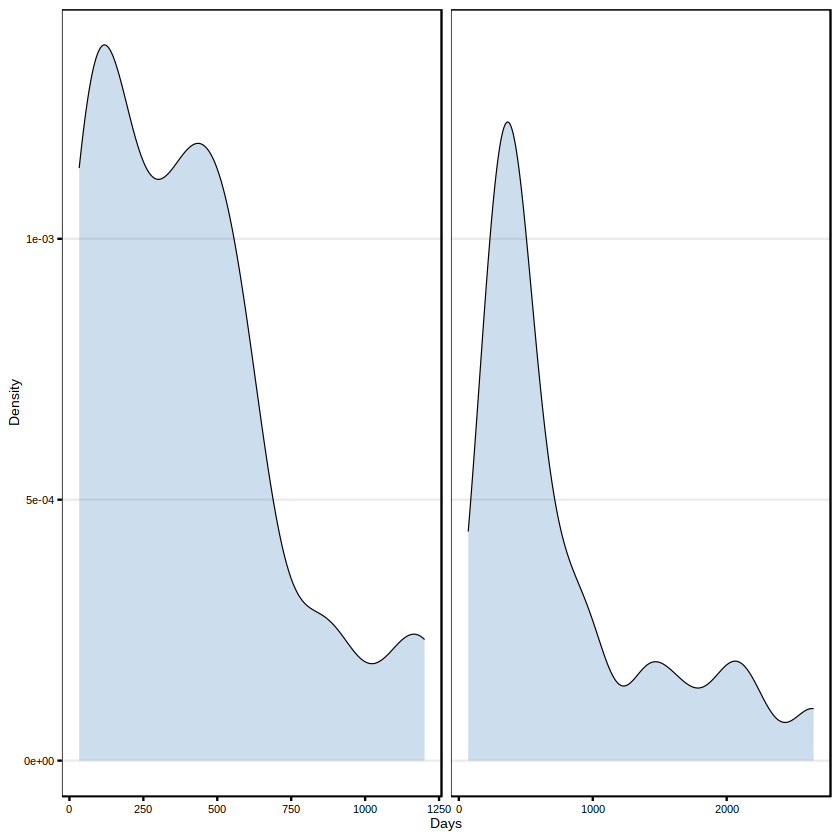

In [5]:
timing_all %>%
    ggplot(aes(x=days))+
    geom_density(adjust = .75,
            fill = COLORs[["GVHD+"]], color = "black", 
            size = 0.25, alpha = 0.25)+
    theme_cfrna_print()+
    theme(
      legend.position = "none",
      panel.grid.minor = element_blank(),       # Remove minor gridlines
      panel.grid.major.x = element_blank()        # Remove major x gridlines
    )+
    theme(strip.background = element_blank(), strip.text = element_blank())+
    labs(x = "Days", y="Density")+
  theme(plot.title = element_blank())+
  facet_wrap(~GRP, scales = "free_x")

  ggsave("./figures/timing_density.pdf", width = 3.75, height = 1.65, units="in")

---
# pairwise

### select samples

In [ ]:
TIME = c("taper_start", "taper_end")
mdf_cghvd <- mdf %>% 
    filter(timepoint %in% TIME) 

table(mdf_cghvd$timepoint, !is.na(mdf_cghvd$date_cgvhd), useNA= "always")

             
              FALSE TRUE <NA>
  taper_start    23   26    0
  taper_end       8    9    0
  wk2_pt          0    0    0
  mo1_pt          0    0    0
  mo3_pt          0    0    0
  mo6_pt          0    0    0
  cGVHD           0    0    0
  <NA>            0    0    0

### pairwise comparisons

In [ ]:
EXP = "taper_start"


### run wilcoxon tests
all_metrics = c(colnames(metrics),colnames(decon))
all_metrics = all_metrics[!all_metrics %in% c("sample_id","Record_ID","timepoint")]

all_res_wilcox = lapply(all_metrics, function(X) {

    g1= mdf_cghvd %>% 
        filter(timepoint == EXP) %>%
        # filter(expGroup == EXP) %>% 
        filter(is.na(date_cgvhd)) %>% pull(X) %>% as.numeric()
    g2= mdf_cghvd %>% 
        filter(timepoint == EXP) %>% 
        # filter(expGroup == EXP) %>% 
        filter(!is.na(date_cgvhd)) %>% pull(X) %>% as.numeric()

    FC= median(g2) / median(g1)
    res = suppressWarnings(wilcox.test(g1,g2))

    return(c(X=X, p=res$p.value, fc = FC)) }
    ) 
    
    
all_res_wilcox = all_res_wilcox %>%  do.call(rbind, .) %>% as.data.frame()

all_res_wilcox$fc = as.numeric(all_res_wilcox$fc)

all_res_wilcox %>% filter(fc > 1) %>% arrange(p) %>% head(10)
all_res_wilcox %>% filter(fc < 1) %>% arrange(p) %>% head(10)


,X,p,fc
,<chr>,<chr>,<dbl>
1,mature_conventional_dendritic_cell,0.00668479647567217,1.619229
2,bladder_urothelial_cell,0.0110150303650008,10875.540743
3,endothelial_cell,0.0116992034356541,1.416131
4,nonrepHistone_CPM,0.0288188714781639,1.025124
5,neutrophil_activity,0.0526405263114856,32.221361
6,intrahepatic_cholangiocyte,0.0552005780117229,19.749645
7,salivary_gland_cell,0.0695686344875144,1.047947
8,immature_enterocyte_intestinal_crypt_stem_cell_intestinal_crypt_stem_cell_of_small_intestine_transit_amplifying_cell_of_large_intestine,0.0727752524430676,1.019272
9,monocyte_decon,0.131276072017554,1.067800


,X,p,fc
,<chr>,<chr>,<dbl>
1,Pegivirus_CPM,0.019598203552543,7.023544e-02
2,t_cell,0.0412581812530046,4.879908e-05
3,duodenum_glandular_cell,0.220091546315469,5.404072e-14
4,pancreatic_pp_cell,0.235604012092579,4.886251e-01
5,kidney_epithelial_cell,0.243638372148427,4.912410e-01
6,G2M_Z,0.324440885324976,7.029968e-01
7,rbc_decon,0.334369897783974,5.498227e-01
8,erythrocyte_erythroid_progenitor,0.334369897783974,5.498227e-01
9,platelet_CBC,0.336174581990294,9.065657e-01


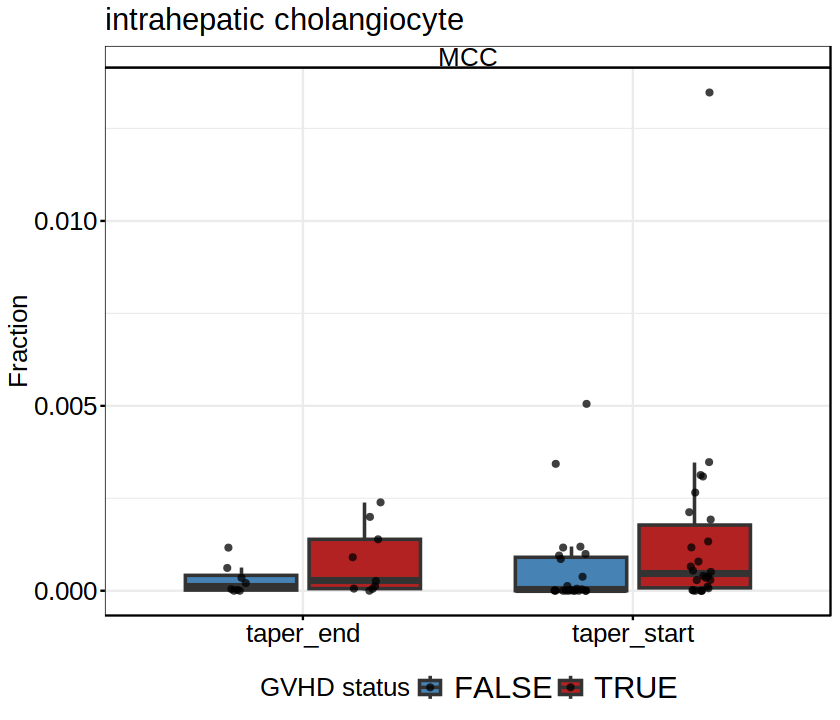

In [ ]:

VAR = "endothelial_cell"
VAR = "intrahepatic_cholangiocyte"


options(repr.plot.width=7, repr.plot.height=6)

mdf_cghvd %>% 
    ggplot(aes(x=timepoint, y=!!sym(VAR), fill =  !is.na(date_cgvhd))) +
    # ggplot(aes(x=expGroup, y=!!sym(VAR), fill =  !is.na(date_cgvhd))) +
    geom_boxplot(outlier.shape=NA,size= 0.75)+
    geom_point(position =  position_jitterdodge(jitter.height=0, 
                                                jitter.width=.1, 
                                                seed=42),
                size = 2, alpha = 0.75, stroke=NA)+
    theme_cfrna_slides()+
    labs(title = gsub("_"," ",VAR), y = "Fraction", x = "Timepoint", fill = "GVHD status")+
    theme(axis.title.x = element_blank(), 
        legend.position = "bottom",
        legend.text = element_text(size = 18))+
    # coord_cartesian(ylim = c(0,0.001))+
    ggh4x::facet_grid2(.~ORIGIN, scales = "free", independent = "y")+
    scale_fill_manual(values = c("FALSE" = "#4682B4", "TRUE" = "#B22222"))


---
# Decon plots

In [14]:
library(patchwork)

In [15]:
EVENTS_box = c("Taper\nstart","Taper\nend","Failure")
EVENTS_line = c("Taper\nstart","Taper\nend","2 Week","1 month","2 month","3 month","6 month")

EVENTS_box = c("Taper Start","Taper End","Failure")

EVENTS_line = c("Taper Start","Taper End","2 Week","1 Month","2 Month","3 Month","6 Month")


mdf_taper <- mdf %>%
    mutate(timepoint_sym = gsub("\n"," ",timepoint_sym)) %>%
    mutate(expGroup = ifelse(!is.na(date_cgvhd),"Failure","Success")) 


# follow up samples
long_ids = mdf %>% 
    filter(timepoint %in% c("wk2_pt","mo1_pt","mo3_pt","mo6_pt")) %>% 
    pull(Record_ID)

long_ids = mdf %>% 
    filter(Record_ID %in% long_ids) %>%
    group_by(Record_ID) %>% summarize(n=n()) %>% filter(n > 1) %>% pull(Record_ID)




In [16]:
table(mdf_taper$timepoint_sym, mdf_taper$expGroup)

             
              Failure Success
  1 Month           2       1
  2 Week            3       2
  3 Month           5       4
  6 Month           2       3
  Failure          12       0
  Taper End         9       8
  Taper Start      26      23

In [17]:
VAR = "mature_conventional_dendritic_cell"

#############################
## BOX PLOT
#############################

boxplot = mdf_taper %>% 

    mutate(timepoint_sym = factor(timepoint_sym, levels = EVENTS_box)) %>%
    filter(!is.na(timepoint_sym)) %>%

    ggplot(aes(x=timepoint_sym, y=!!sym(VAR), fill =  expGroup, color = expGroup)) +
    geom_boxplot(outlier.shape = NA, position = position_dodge(width = 0.8), width = 0.7, alpha = 0.25, size = 0.1) +

    geom_point(size = 1, alpha = 0.75, stroke=NA,
                position =  position_jitterdodge(jitter.height=0, 
                                                jitter.width=.2, 
                                                seed=42)
                )+
    theme_cfrna_print() +
    theme(
        plot.margin=unit(c(0,0,0,0), "pt"),
        axis.text.x = element_text(size = 6, angle = 45, hjust = 1),
        axis.title.x = element_blank(),
        panel.grid.major.x = element_blank()        # Remove major x gridlines
        )+
    labs(y="Fraction")+
    scale_fill_manual(values = COLORs)+
    scale_color_manual(values = COLORs)+
    theme(plot.title = element_blank()) 


#############################
## LINE PLOT
#############################

lineplot = mdf_taper %>%     
    mutate(timepoint_sym = gsub("\n"," ",timepoint_sym)) %>%

    mutate(timepoint_sym = factor(timepoint_sym, levels = EVENTS_line)) %>%
    filter(!is.na(timepoint_sym)) %>% 

    filter(Record_ID %in% long_ids) %>%

    ggplot(aes(x=timepoint_sym, y=!!sym(VAR), color =  expGroup, group=Record_ID)) +
    geom_line()+
    geom_point(size = 1, alpha = 0.75, stroke=NA)+
    
    theme_cfrna_print() +
    theme(
        plot.margin=unit(c(0,0,0,0), "pt"),
        axis.text.y = element_blank(),
        axis.text.x = element_text(size = 6, angle = 45, hjust = 1),
        axis.ticks.y = element_blank(),
        axis.title = element_blank(),
        panel.grid.major.x = element_blank()        # Remove major x gridlines
        )+
    scale_fill_manual(values = COLORs)+
    scale_color_manual(values = COLORs)+
    theme(plot.title = element_blank()) 

## align ylimits
ymax = max(layer_scales(boxplot)$y$range$range[2], layer_scales(lineplot)$y$range$range[2])
ymin = min(layer_scales(boxplot)$y$range$range[1], layer_scales(lineplot)$y$range$range[1])
ymin = 0
boxplot = boxplot + coord_cartesian(ylim = c(ymin,ymax))
lineplot = lineplot + coord_cartesian(ylim = c(ymin,ymax))

boxplot_dend = boxplot
lineplot_dend = lineplot
  

Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”


In [18]:
VAR = "endothelial_cell"

#############################
## BOX PLOT
#############################

boxplot = mdf_taper %>% 

    mutate(timepoint_sym = factor(timepoint_sym, levels = EVENTS_box)) %>%
    filter(!is.na(timepoint_sym)) %>%

    ggplot(aes(x=timepoint_sym, y=!!sym(VAR), fill =  expGroup, color = expGroup)) +
    geom_boxplot(outlier.shape = NA, position = position_dodge(width = 0.8), width = 0.7, alpha = 0.25, size = 0.1) +

    geom_point(size = 1, alpha = 0.75, stroke=NA,
                position =  position_jitterdodge(jitter.height=0, 
                                                jitter.width=.2, 
                                                seed=42)
                )+
    theme_cfrna_print() +
    theme(
        plot.margin=unit(c(0,0,0,0), "pt"),
        axis.text.x = element_text(size = 6, angle = 45, hjust = 1),
        axis.title.x = element_blank(),
        panel.grid.major.x = element_blank()        # Remove major x gridlines
        )+
    labs(y="Fraction")+
    scale_fill_manual(values = COLORs)+
    scale_color_manual(values = COLORs)+
    theme(plot.title = element_blank()) 


#############################
## LINE PLOT
#############################

lineplot = mdf_taper %>%     
    mutate(timepoint_sym = gsub("\n"," ",timepoint_sym)) %>%

    mutate(timepoint_sym = factor(timepoint_sym, levels = EVENTS_line)) %>%
    filter(!is.na(timepoint_sym)) %>% 

    filter(Record_ID %in% long_ids) %>%

    ggplot(aes(x=timepoint_sym, y=!!sym(VAR), color =  expGroup, group=Record_ID)) +
    geom_line()+
    geom_point(size = 1, alpha = 0.75, stroke=NA)+
    
    theme_cfrna_print() +
    theme(
        plot.margin=unit(c(0,0,0,0), "pt"),
        axis.text.y = element_blank(),
        axis.text.x = element_text(size = 6, angle = 45, hjust = 1),
        axis.ticks.y = element_blank(),
        axis.title = element_blank(),
        panel.grid.major.x = element_blank()        # Remove major x gridlines
        )+
    scale_fill_manual(values = COLORs)+
    scale_color_manual(values = COLORs)+
    theme(plot.title = element_blank()) 

## align ylimits
ymax = max(layer_scales(boxplot)$y$range$range[2], layer_scales(lineplot)$y$range$range[2])
ymin = min(layer_scales(boxplot)$y$range$range[1], layer_scales(lineplot)$y$range$range[1])
ymin = 0
boxplot = boxplot + coord_cartesian(ylim = c(ymin,ymax))
lineplot = lineplot + coord_cartesian(ylim = c(ymin,ymax))

boxplot_end = boxplot
lineplot_end = lineplot

Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”


In [19]:
boxplot_dend_sig = boxplot_dend + stat_compare_means(
      aes(group = expGroup, label = after_stat(p.signif)),
      method = "wilcox.test",
      symnum.args = list(cutpoints = c(0, 0.0001, 0.001, 0.01, 0.1, Inf), symbols = c("****", "***", "**", "*", "ns")),
      size = 2,
      label.y = 0.048
      )

# boxplot_dend_sig

boxplot_end_sig = boxplot_end + stat_compare_means(
      aes(group = expGroup, label = after_stat(p.signif)),
      method = "wilcox.test",
      symnum.args = list(cutpoints = c(0, 0.0001, 0.001, 0.01, 0.1, Inf), symbols = c("****", "***", "**", "*", "ns")),
      size = 2,
      label.y = 0.23
      )

In [20]:
t1 = mdf_taper %>% 
    filter(timepoint_sym == "Taper Start") %>% 
    filter(expGroup == "Success") %>%
    pull(endothelial_cell)
t2 = mdf_taper %>% 
    filter(timepoint_sym == "Taper Start") %>% 
    filter(expGroup == "Failure") %>%
    pull(endothelial_cell)

wilcox.test(t1,t2)


	Wilcoxon rank sum exact test

data:  t1 and t2
W = 174, p-value = 0.0117
alternative hypothesis: true location shift is not equal to 0


Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”


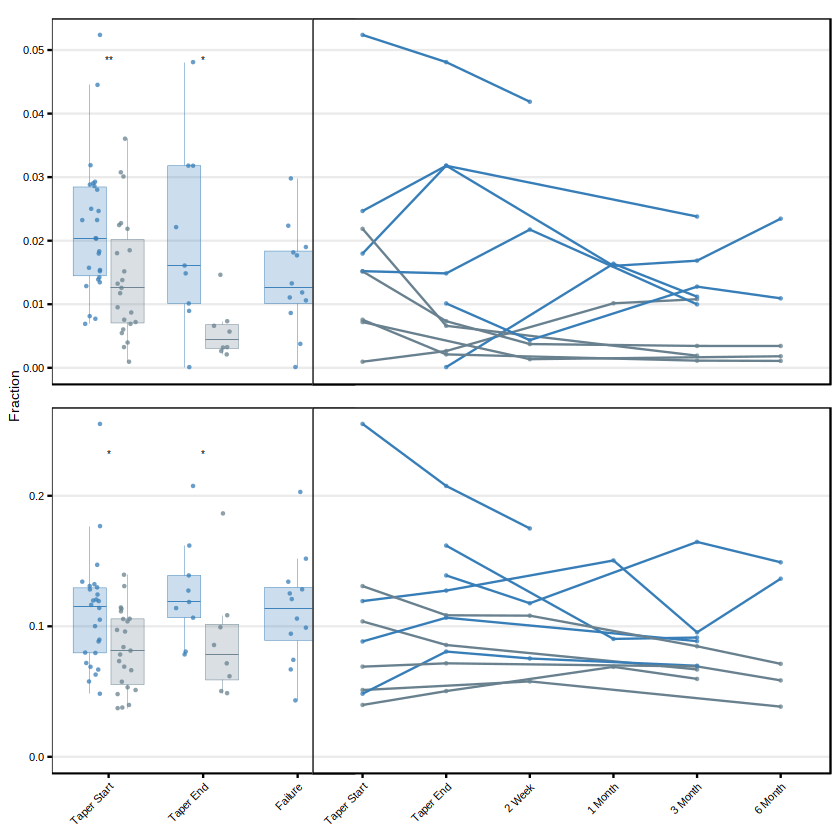

In [21]:
WIDTH = 3
HEIGHT = 3.45

boxplot_dend_F = boxplot_dend_sig + theme(axis.text.x = element_blank(), axis.ticks.x = element_blank())
lineplot_dend_F = lineplot_dend + theme(axis.text.x = element_blank(), axis.ticks.x = element_blank())

boxplot_end_F = boxplot_end_sig
lineplot_end_F = lineplot_end

boxplot_dend_F + plot_spacer() + lineplot_dend_F + 
boxplot_end_F + plot_spacer() + lineplot_end_F + 
plot_layout(widths = c(7, -1.5, 12), axis_titles = "collect")
# plot_layout(design = layout, widths = c(9, -1.5, 12))

ggsave("./figures/BOXLINE_both.pdf", width = WIDTH, height = HEIGHT, units="in")

---
# Gene level

In [3]:
suppressMessages(library(DESeq2))

In [4]:
## variables to use for DESeq2
SAMPLE_ID_VAR = "sample_id"
COMP_VAR = "sample_group"
GROUPS = c("COMP", "REF")  

##------------------------------------
# Load metadata and count matrix
mdf_mcc_daa <- mdf %>%
    filter( as.numeric(ymd(date_cgvhd) - ymd(date)) >=0 | is.na(date_cgvhd)) %>%
    filter(timepoint %in%c("taper_start", "taper_end", "wk2_pt", "mo1_pt", "mo3_pt", "mo6_pt")) %>%   ## previously done with "taper_start" removed, this led to 573 dags
    mutate(expGroup = ifelse(!is.na(date_cgvhd), "failure", "success")) 

### get counts
counts = read.delim("../1_DATA/counts_sQC_gAll_nRaw.tsv")
counts_daa = counts[,mdf_mcc_daa$sample_id]



## dun deseq2

In [5]:
# ##------------------------------------
# Construct DESeq Data Set
dds <- DESeqDataSetFromMatrix(counts_daa,
                                colData = mdf_mcc_daa,
                                design = ~ expGroup)

##------------------------------------
# Run differntial abundance analysis
dds <- DESeq(dds)

# Normalize counts and estimate size factors
dds <- estimateSizeFactors(dds)
# Compute baseMean and filter genes
baseMean_values <- rowMeans(counts(dds, normalized=TRUE))
dds <- dds[baseMean_values > 50, ]

# get counts
res <- results(dds,contrast = c("expGroup","failure","success"))
res_df <- res %>% data.frame()
res_df <- merge(res_df, gene_key, by.x=0, by.y="gene_id")

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 245 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing



In [6]:
res_df %>% write.csv("./outputs/hsct_cfrna_DataS4.csv",quote=FALSE)


In [25]:
res_df %>% filter(padj < 0.1) %>% nrow

[1] 836

## volcano

Warning message in geom_text_repel(size = 2, max.overlaps = Inf, min.segment.length = 0, :
“Ignoring unknown parameters: `fill`”


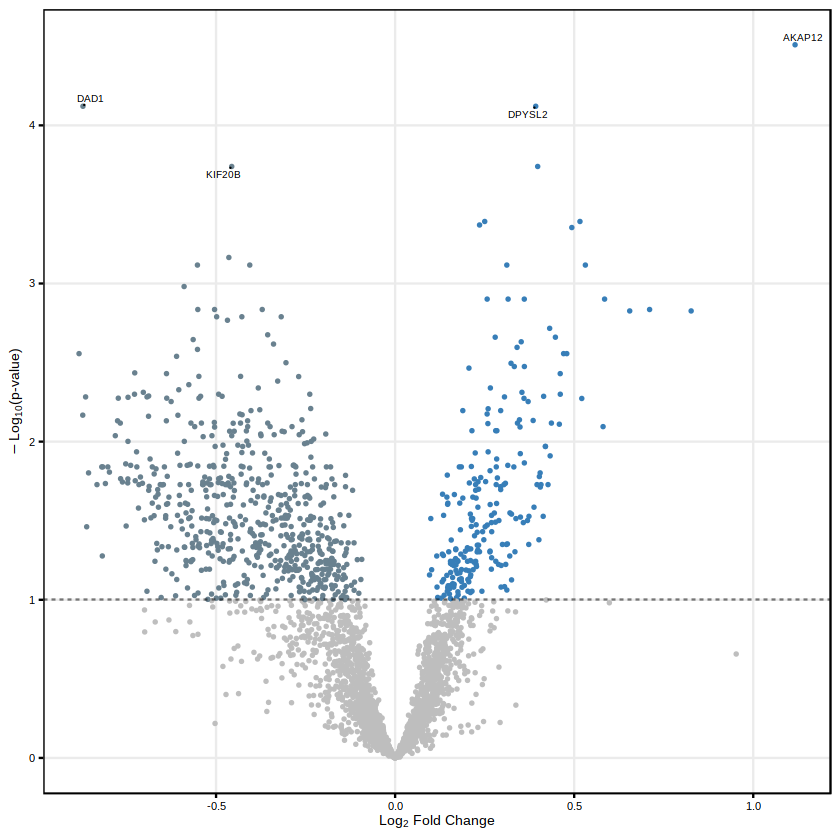

In [26]:
library(ggrepel)

PADJ_THRESH = 0.1
LFC_THRESH = 0.25

### extract results and label "up", "down", "notsig"
detable <- res_df %>%
    mutate(sig_dir = case_when(
        padj<PADJ_THRESH & log2FoldChange > 0 ~ "up",
        padj<PADJ_THRESH & log2FoldChange < 0  ~"down",
        .default = "notsig"))

GENEs = c("AKAP12","DPYSL2","DAD1","KIF20B")
top_all = c(GENEs)
# top_all = c()
detable <- detable %>% mutate(delabel = ifelse(gene_name %in% top_all,gene_name,""))



# create plot
vol_plt <- detable %>% 
    # filter(baseMean > 50) %>% 
    # filter(gene_type == "protein_coding") %>% 
    filter(!is.na(padj)) %>%
    ggplot(aes(x=log2FoldChange, y=-log10(padj), color = sig_dir, label=delabel)) + #
    geom_point(size = 0.5) +
    geom_hline(yintercept = -log10(PADJ_THRESH), size = 0.5, alpha = 0.5, linetype="dashed")+
    # geom_vline(xintercept = c(-LFC_THRESH, LFC_THRESH), size = 0.5, alpha = 0.5, linetype="dashed") + 
    geom_text_repel(size = 2, 
        max.overlaps=Inf, 
        min.segment.length = 0, 
        color = "black", 
        fill="white",
        box.padding = 0.1
        # xlim = c(-Inf, Inf), ylim = c(-Inf, Inf)
        ) +
    theme_cfrna_print() +
    theme(
      panel.grid.minor.x = element_blank()        # Remove major x gridlines
    )+
    labs(x = bquote(Log[2]*" Fold Change"), y= bquote(-Log[10]*"(p-value)")) +
    scale_color_manual(values = c("notsig"="grey","up"=COLORs[["Failure"]],"down"=COLORs[["Success"]]))

vol_plt

WIDTH = 2
HEIGHT = 2

ggsave("figures/MCC_VOLCANO.plt.pdf", vol_plt, width = WIDTH, height = HEIGHT, dpi = 300)

## gene counts

In [19]:
res_df %>% arrange(padj) %>% head

,Row.names,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene_name,gene_type
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
1,ENSG00000131016.17,98.56665,1.1168009,0.19423455,5.749754,8.937326e-09,3.094102e-05,AKAP12,protein_coding
2,ENSG00000092964.18,177.03280,0.3926256,0.07251704,5.414253,6.154525e-08,7.574007e-05,DPYSL2,protein_coding
3,ENSG00000129562.11,73.31739,-0.8717080,0.16134571,-5.402734,6.563264e-08,7.574007e-05,DAD1,protein_coding
4,ENSG00000138182.15,64.48169,-0.4562252,0.08861653,-5.148308,2.628463e-07,1.819948e-04,KIF20B,protein_coding
5,ENSG00000145391.14,65.75821,0.3981100,0.07687818,5.178452,2.237351e-07,1.819948e-04,SETD7,protein_coding
6,ENSG00000138119.17,76.92792,0.5161578,0.10465147,4.932160,8.132534e-07,4.053900e-04,MYOF,protein_coding


In [31]:
EVENTS_box = c("Taper start","Taper end","Failure")
EVENTS_line = c("Taper Start","Taper End","2 Week","1 Month","2 Month","3 Month","6 Month")



mdf_cnts <- mdf %>%
    mutate(timepoint_sym = gsub("\n"," ",timepoint_sym)) %>%
    mutate(expGroup = ifelse(!is.na(date_cgvhd),"Failure","Success")) 


# follow up samples
long_ids = mdf %>% 
    filter(timepoint %in% c("wk2_pt","mo1_pt","mo3_pt","mo6_pt")) %>% 
    pull(Record_ID)

long_ids = mdf %>% 
    filter(Record_ID %in% long_ids) %>%
    group_by(Record_ID) %>% summarize(n=n()) %>% filter(n > 1) %>% pull(Record_ID)

counts_cnts= counts[,mdf_cnts$sample_id]

In [32]:
GENEs = c("AKAP12","DPYSL2","DAD1","KIF20B")
GENEs = c("AKAP12","DAD1")


GENEIDS = gene_key %>% filter(gene_name %in% GENEs) %>% pull(gene_id)

### Normalize counts
CNTS = edgeR::cpm(counts_cnts)

### Combine counts with metadata
cnt_df = merge(mdf_cnts %>% select(sample_id, date_cgvhd, expGroup, timepoint_sym,Record_ID), 
        data.frame(t(CNTS[GENEIDS,,drop=FALSE])),
        by.x="sample_id",by.y=0) %>% 
    reshape2::melt(id.vars = c("sample_id","date_cgvhd", "expGroup","timepoint_sym","Record_ID"), variable.name = "gene_id",value.name = "counts")

### Add gene names for plotting
cnt_df = merge(cnt_df, gene_key, by.x="gene_id", by.y="gene_id") %>% 
    mutate(gene_name = factor(gene_name, levels = GENEs))

WIDTH = 2
HEIGHT = 2

In [33]:
cnt_df_sub %>% head

gene_id,sample_id,date_cgvhd,expGroup,timepoint_sym,Record_ID,counts,gene_name,gene_type
<fct>,<chr>,<chr>,<chr>,<fct>,<chr>,<dbl>,<fct>,<chr>


Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”


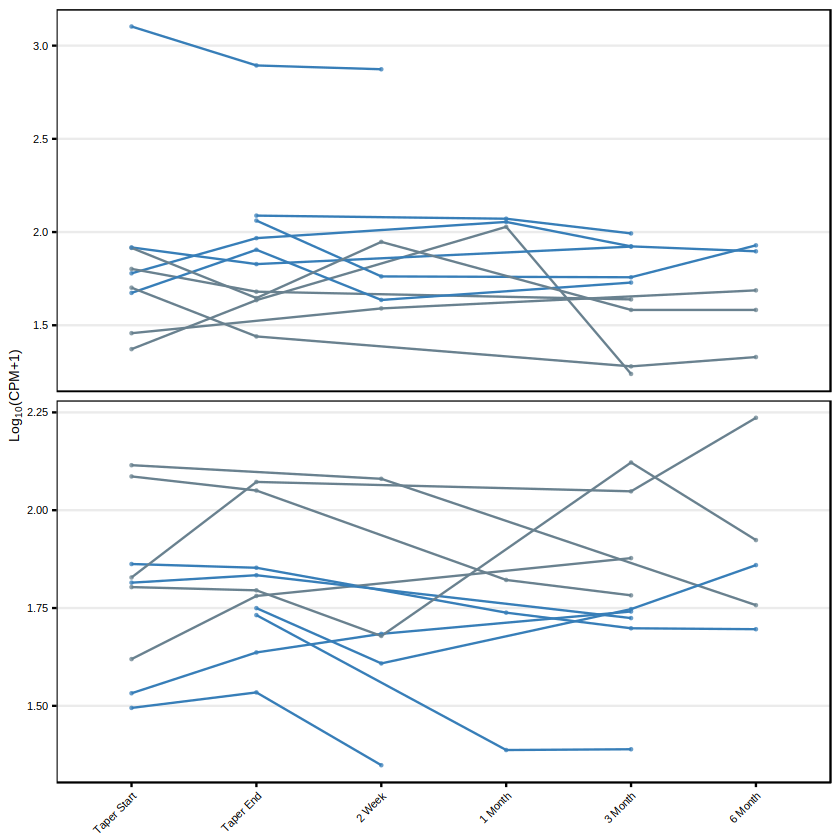

In [34]:
ymax= 250

cnt_df_sub = cnt_df %>% filter(gene_name %in% GENEs) %>% 
mutate(timepoint_sym = factor(timepoint_sym, levels = EVENTS_line)) %>%
    filter(!is.na(timepoint_sym)) %>% 

    filter(Record_ID %in% long_ids)

VAR = "counts"


#############################
## MYOF
ln_plt = cnt_df_sub %>%     

    ggplot(aes(x=timepoint_sym, y=log10(counts+1), color =  expGroup, group=Record_ID)) +
    geom_line()+
    geom_point(size = 1, alpha = 0.75, stroke=NA)+
    labs(y = bquote(Log[10]*"(CPM+1)"))+
    theme_cfrna_print() +
    theme(
        strip.text = element_blank(),
        axis.text.x = element_text(size = 6, angle = 45, hjust = 1),
        strip.background = element_blank(),
        axis.title.x = element_blank(),
        legend.position = "none",
        panel.grid.minor.y = element_blank(),       # Remove minor gridlines
        panel.grid.major.x = element_blank()        # Remove major x gridlines
        )+
    scale_fill_manual(values = COLORs)+
    scale_color_manual(values = COLORs)+
    facet_wrap(~gene_name,ncol=1, scales = "free_y")


ln_plt

ggsave("./figures/LINE_GENE.pdf",width = WIDTH, height = HEIGHT, units="in")

---
# Modeling

In [35]:
## variables to use for DESeq2
SAMPLE_ID_VAR = "sample_id"
COMP_VAR = "sample_group"
GROUPS = c("COMP", "REF")  

##------------------------------------
# Load metadata and count matrix
mdf_mcc_daa <- mdf %>%
    filter( as.numeric(ymd(date_cgvhd) - ymd(date)) >= 0 | is.na(date_cgvhd)) %>%
    mutate(expGroup = ifelse(!is.na(date_cgvhd), "failure", "success"))  
  
### load counts
counts = read.delim("../1_DATA/counts_sQC_gAll_nRaw.tsv")[,mdf_mcc_daa$sample_id]


### save outputs to run in python
library(edgeR)

dge = DGEList(counts = counts)
dge = calcNormFactors(dge, method = "TMM")
cpm_values = cpm(dge, log = TRUE)

# cpm_values %>% write.csv("./modeling/modeling_counts_cpm_tmm_log.csv", row.names=TRUE, quote=FALSE)
# mdf_mcc_daa %>% write.csv("./modeling/modeling_metadata.csv",row.names=FALSE,quote=FALSE)

Loading required package: limma


Attaching package: ‘limma’


The following object is masked from ‘package:DESeq2’:

    plotMA


The following object is masked from ‘package:BiocGenerics’:

    plotMA




### load outputs

In [36]:
scores = read.csv("./modeling/classifier_scores.csv") 
scores_df = merge(mdf_mcc_daa, scores, by="sample_id") %>% 
    filter(iteration == 40)

scores_df %>% head()

,sample_id,Record_ID,date,timepoint,SCALE_qubit,sample_group,all_comps,transplant_date,date_taper_start,date_taper_end,⋯,club_cell_type_i_pneumocyte,pulmonary_ionocyte,pancreatic_pp_cell,pancreatic_delta_cell,duodenum_glandular_cell,thymocyte,expGroup,iteration,train_or_test,classifier_score
,<chr>,<chr>,<chr>,<fct>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>,<dbl>
1,MCC17948_cfRNA_1_bp61x61,MCC_1,2015-10-12,taper_start,1.425492e-07,COMP,_cgvhd,2014-09-30,2015-10-12,2016-05-18,⋯,1.193612e-17,2.005716e-19,8.658919e-05,6.163995e-20,8.188336e-20,0.013013703,failure,40,test,0.0532347292
2,MCC17948_cfRNA_10_bp61x61,MCC_8,2016-11-16,cGVHD,2.660249e-07,COMP,_cgvhd,2013-06-25,2016-02-03,NA,⋯,8.323051e-20,2.628525e-13,2.092793e-04,9.647550e-20,7.048346e-20,0.038886578,failure,40,train,0.0009601519
3,MCC17948_cfRNA_13_bp61x61,MCC_11,2016-02-24,taper_start,3.029318e-07,REF,,2014-02-20,2016-02-24,2016-11-05,⋯,8.800593e-20,8.850390e-20,9.406599e-05,1.048804e-05,7.264111e-20,0.015655661,success,40,train,0.9988188679
4,MCC17948_cfRNA_14_bp61x61,MCC_11,2017-02-15,taper_end,1.363754e-07,REF,,2014-02-20,2016-02-24,2016-11-05,⋯,2.940386e-06,9.354661e-20,1.666494e-04,9.140378e-20,5.436514e-20,0.022181629,success,40,train,0.9989478466
5,MCC17948_cfRNA_15_bp61x61,MCC_13,2016-05-16,taper_start,2.148277e-07,REF,,2015-10-02,2016-05-16,2017-02-27,⋯,9.081214e-20,1.361316e-05,1.906146e-04,9.514248e-20,5.136880e-20,0.007891109,success,40,train,0.9998676502
6,MCC17948_cfRNA_16_bp61x61,MCC_13,2017-02-27,taper_end,4.291534e-07,REF,,2015-10-02,2016-05-16,2017-02-27,⋯,2.590065e-06,9.679103e-20,1.220213e-04,1.692504e-05,6.228118e-06,0.028645637,success,40,train,0.9993747644


In [37]:
features = read.csv("./modeling/selected_features.csv")
features_df = merge(features, gene_key, by.x="feature", by.y="gene_id")
features_df %>% head


,feature,iteration,coefficient,gene_name,gene_type
,<chr>,<int>,<dbl>,<chr>,<chr>
1,ENSG00000000460.17,38,0.008002023,C1orf112,protein_coding
2,ENSG00000000460.17,47,0.017307563,C1orf112,protein_coding
3,ENSG00000000460.17,10,0.000375886,C1orf112,protein_coding
4,ENSG00000000460.17,71,0.004666916,C1orf112,protein_coding
5,ENSG00000000460.17,50,0.003100591,C1orf112,protein_coding
6,ENSG00000000971.16,6,-0.017822530,CFH,protein_coding


### ROC

Warning message in ci.auc.roc(roc, ...):
“ci.auc() of a ROC curve with AUC == 1 is always 1-1 and can be misleading.”


Area under the curve: 100%
Area under the curve: 77.21%


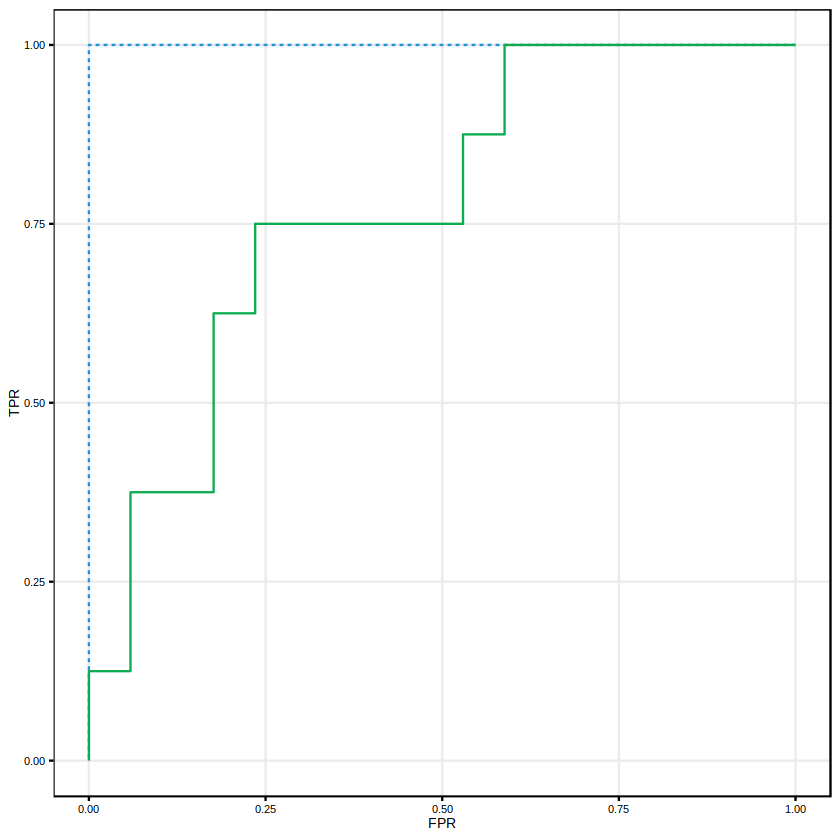

In [38]:
suppressMessages(library(pROC))
##------------------------------------
## ROC plot
##------------------------------------

train_mdf = scores_df %>% filter(train_or_test == "train")
roc_train <- suppressMessages(roc(response = train_mdf$expGroup, predictor = train_mdf$classifier_score,
                percent=TRUE,
                ci=TRUE, 
                boot.n=10000, boot.stratified=TRUE,
                print.auc=TRUE,
                print.thres="best",
                print.thres.best.method="youden"))

test_mdf = scores_df %>% filter(train_or_test == "test")
roc_test <- suppressMessages(roc(response = test_mdf$expGroup, predictor = test_mdf$classifier_score,
                percent=TRUE,
                ci=TRUE, 
                boot.n=10000, boot.stratified=TRUE,
                print.auc=TRUE,
                print.thres="best",
                print.thres.best.method="youden"))

##------------------------------------
## get roc values
##------------------------------------

train_roc <- data.frame("sensitivity" = roc_train$sensitivities,
                        "specificity" = roc_train$specificities,
                       "set" = "train")

test_roc <- data.frame("sensitivity" = roc_test$sensitivities,
                        "specificity" = roc_test$specificities,
                       "set" = "test")


all_roc <- do.call("rbind",list(train_roc, test_roc)) %>%
    mutate(FPR = 1-(as.numeric(specificity)/100),
          TPR = as.numeric(sensitivity)/100)


## malke plot

roc_plt = all_roc %>% 
    mutate(set = factor(set,levels = c("train","validate","test"))) %>% 
    ggplot(aes(x= FPR, y= TPR, group = set, linetype = set, color = set))+
    geom_path()+
    theme_cfrna_print()+
    scale_linetype_manual(values = c("train"="dashed","test"="solid"))+
    scale_color_manual(values = c("train"="#2495D6","test"="#0DAC50"))
    
roc_plt

WIDTH = 2.1
HEIGHT = 2
ggsave("./figures/MCC_ROC.pdf", width = WIDTH, height = HEIGHT)

print(roc_train$auc)
print(roc_test$auc)

## explore features

In [39]:
features_df %>% 
    group_by(iteration) %>% summarize(n=n()) %>% 
    pull(n) %>% summary()

features_df %>% 
    group_by(feature) %>% summarize(n=n()) %>% 
    pull(n) %>% summary()

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    4.0   327.0   502.0   447.3   585.0   898.0 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.000   1.000   3.000   9.746  10.000 100.000 

In [40]:
top_features = features_df %>% 
    group_by(feature,gene_name) %>% 
    summarize(n=n(),mean_c = mean(coefficient), max_c = max(coefficient), min_c = min(coefficient)) %>% 
    arrange(desc(n),max_c) %>% 
    head(15) 

order = top_features$gene_name
top_features$gene_name = factor(top_features$gene_name, levels = rev(order))


`summarise()` has grouped output by 'feature'. You can override using the
`.groups` argument.


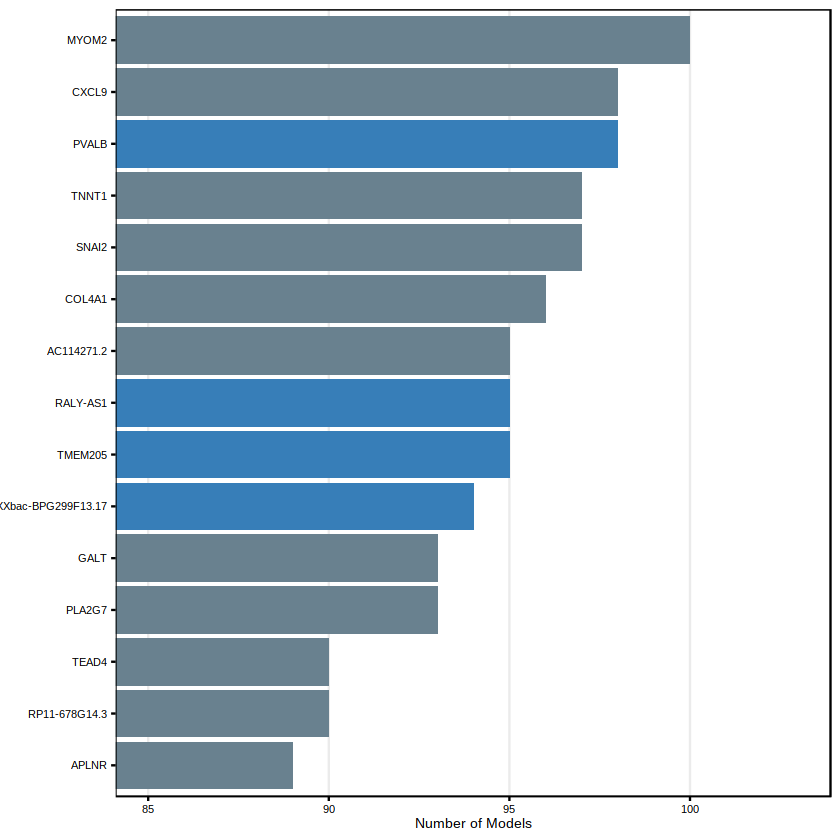

In [41]:
ft_plt = top_features %>% 
    mutate(dir = ifelse(mean_c > 0,"up","down")) %>%
    ggplot(aes(x=n, y=gene_name, fill = dir))+
    geom_bar(stat="identity")+
    theme_cfrna_print()+
    labs(x="Number of Models")+
    theme(axis.title.y=element_blank())+
    theme(
                panel.grid.major.y = element_blank()
        )+
    coord_cartesian(xlim = c(85,103))+
    scale_fill_manual(values = c("down"=COLORs[['Success']],"up"=COLORs[['Failure']]))

ft_plt

WIDTH= 2.5
HEIGHT= 2
ggsave("./figures/MCC_FEATURES.pdf", width = WIDTH, height = HEIGHT)

---
# Combine plts

In [42]:
library(patchwork)

Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”


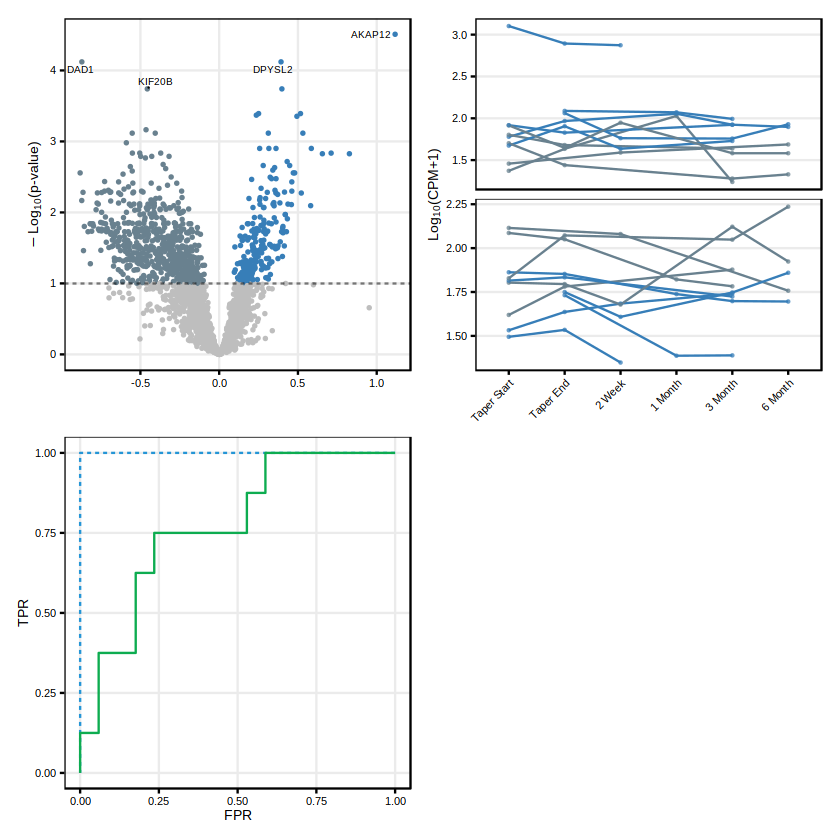

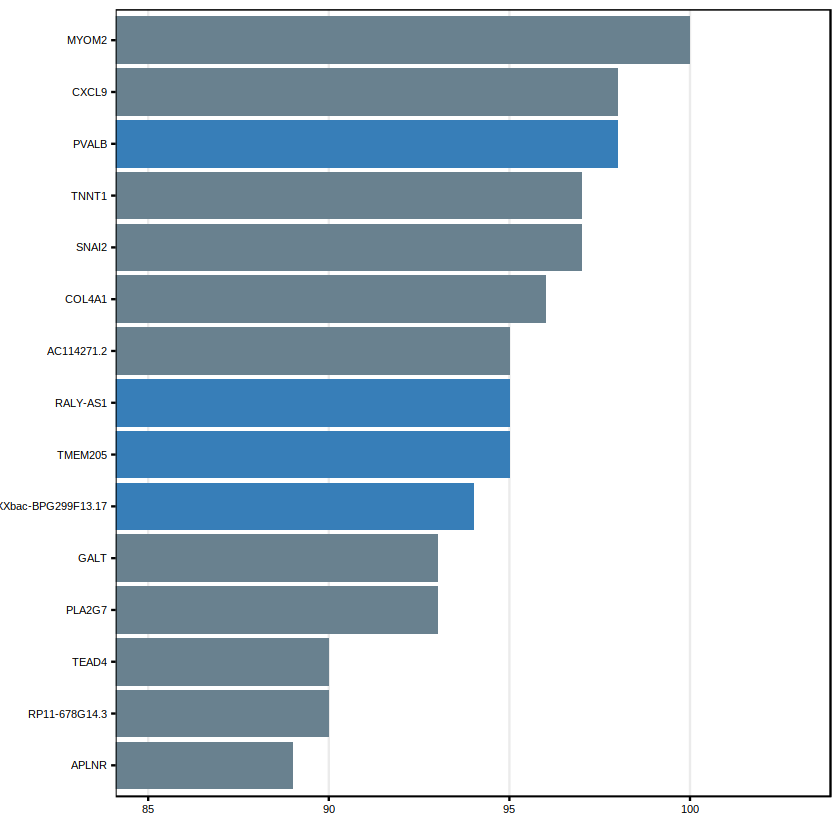

In [43]:
ln_plt_fnl = ln_plt #+ theme(axis.title.y = element_text(size = 8, vjust = -20))
# vol_plt_fnl = vol_plt + theme(axis.title.x = element_text(size = 8, vjust = 12))
vol_plt_fnl = vol_plt + theme(axis.title.x = element_blank(), axis.title.y = element_text(size = 8, vjust = -4))



vol_plt_fnl + ln_plt_fnl + roc_plt + plot_spacer()

ggsave("./figures/MCC_all.top.pdf", width = 4, height = 3.75, units = "in")


ft_plt + theme(axis.title.x = element_text(size = 8, hjust = 2))

ggsave("./figures/MCC_all.bottom.pdf", width = 1.9, height = 1.72, units = "in")

Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”


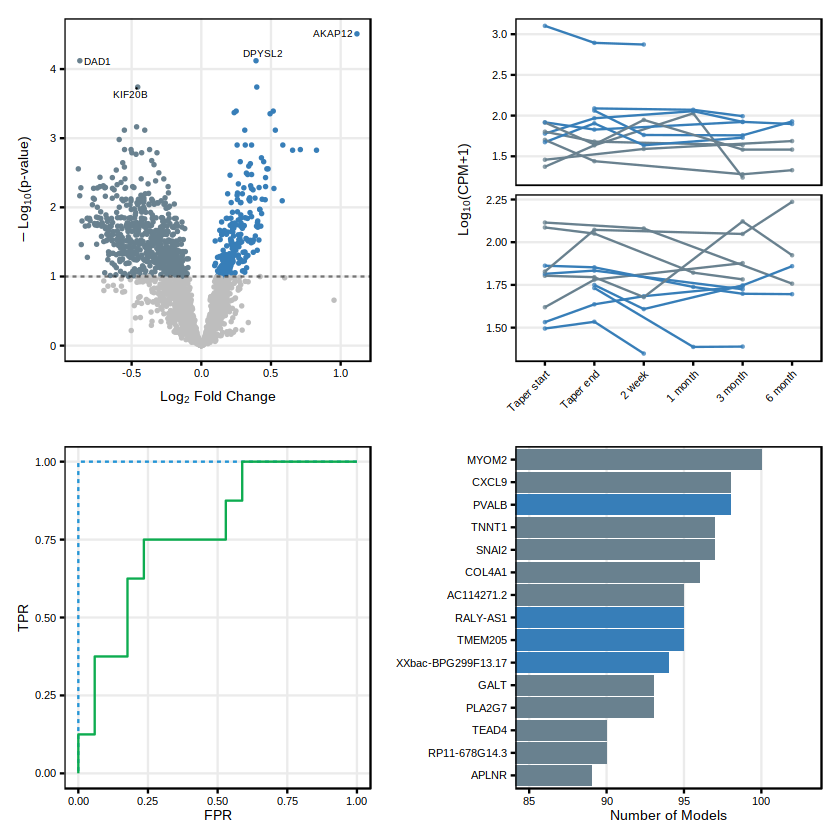

In [ ]:
ln_plt_fnl = ln_plt + theme(axis.title.y = element_text(size = 8, vjust = -20))
vol_plt_fnl = vol_plt + theme(axis.title.x = element_text(size = 8, vjust = 12))


vol_plt_fnl + ln_plt_fnl + roc_plt + ft_plt 

ggsave("./figures/MCC_all.pdf", width = 3.75, height = 3.25, units = "in")

---
# Supplemental Table

In [18]:
mdf %>% pull(Record_ID) %>% unique() %>% length

[1] 53

In [7]:
all %>% head

study_ID,age,gender,donor_gender,disease,HLA_match,GVHD_ppx,graft
<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,70,M,M,MDS,match,SIR/TAC,PBSC
2,51,F,F,MM,match,MMF/TAC,PBSC
3,62,M,M,MDS,match,SIR/TAC,PBSC
4,70,F,F,CLL,match,SIR/TAC,PBSC
1-C2,66,F,M,CLL,match,CSA/MMF,PBSC
5,71,F,M,MDS,match,SIR/TAC,PBSC


In [16]:
library(readxl)

all = read_xlsx("/workdir/cjl332/moffitt/1_DATA/data/ASM - TOL biomarker - database - all data - with CBC - ver 9.19.24.xlsx")
colnames(all) = gsub(" ","_",colnames(all))

all = all %>% 
    select(study_ID, age, gender, donor_gender, disease, HLA_match, GVHD_ppx, graft) %>% 
    mutate(study_ID = paste0("MCC_",study_ID)) %>% 
    filter(study_ID %in% mdf$Record_ID) %>% 
    mutate(recipient_donor_gender = paste0(gender, "-", donor_gender))
colnames(all)


New names:
• `onset date` -> `onset date...28`
• `skin` -> `skin...29`
• `GI` -> `GI...30`
• `liver` -> `liver...31`
• `overall` -> `overall...32`
• `max date` -> `max date...33`
• `skin` -> `skin...34`
• `GI` -> `GI...35`
• `liver` -> `liver...36`
• `overall` -> `overall...37`
• `resolution date` -> `resolution date...38`
• `onset date` -> `onset date...40`
• `skin` -> `skin...41`
• `mouth` -> `mouth...42`
• `eye` -> `eye...43`
• `lung` -> `lung...44`
• `GI` -> `GI...45`
• `liver` -> `liver...46`
• `genital` -> `genital...47`
• `jt-fascia` -> `jt-fascia...48`
• `overall` -> `overall...49`
• `max date` -> `max date...50`
• `skin` -> `skin...51`
• `mouth` -> `mouth...52`
• `eye` -> `eye...53`
• `lung` -> `lung...54`
• `GI` -> `GI...55`
• `liver` -> `liver...56`
• `genital` -> `genital...57`
• `jt-fascia` -> `jt-fascia...58`
• `overall` -> `overall...59`
• `resolution date` -> `resolution date...60`
• `initial ppx stop date` -> `initial ppx stop date...61`
• `agent` -> `agent...62`
• `re

[1] "study_ID"               "age"                    "gender"                
[4] "donor_gender"           "disease"                "HLA_match"             
[7] "GVHD_ppx"               "graft"                  "recipient_donor_gender"

In [46]:
# summary(all$age)
# table(all$recipient_donor_gender)
# table(all$disease)
table(all$HLA_match)
# table(all$GVHD_ppx)

table(all$graft)


   match mismatch 
      50        3 


  BM PBSC 
   1   52 

In [ ]:
# acute GVHD grade
'overall'
# chronic GvHD severity
'overall'

In [43]:

c1s = read_xlsx("/workdir/cjl332/moffitt/1_DATA/data/ASM - TOL biomarker - database - all data - with CBC - ver 9.19.24.xlsx", sheet = "serial data - cohort 1")
colnames(c1s) = gsub(" ","_",colnames(c1s))
keepers = colnames(c1s)[grepl("overall",colnames(c1s))]
agvhd_cols = keepers[seq(1, length(keepers), by = 2)]
cgvhd_cols = keepers[seq(2, length(keepers), by = 2)]
aghvd_cols = c1s[,agvhd_cols] %>% apply(.,1,max,na.rm=TRUE)
cghvd_cols = c1s[,cgvhd_cols] %>% apply(.,1,max,na.rm=TRUE)
c1_df = data.frame(study_id = c1s$study_ID, acute_gvhd_c1 = aghvd_cols, chronic_gvhd_c1 = cghvd_cols)

c2s = read_xlsx("/workdir/cjl332/moffitt/1_DATA/data/ASM - TOL biomarker - database - all data - with CBC - ver 9.19.24.xlsx", sheet = "serial data - cohort 2")
colnames(c2s) = gsub(" ","_",colnames(c2s))
keepers = colnames(c2s)[grepl("overall",colnames(c2s))]
agvhd_cols = keepers[seq(1, length(keepers), by = 2)]
cgvhd_cols = keepers[seq(2, length(keepers), by = 2)]
aghvd_cols = c2s[,agvhd_cols] %>% apply(.,1,max,na.rm=TRUE)
cghvd_cols = c2s[,cgvhd_cols] %>% apply(.,1,max,na.rm=TRUE)
c2_df = data.frame(study_id = c2s$study_ID, acute_gvhd_c2 = aghvd_cols, chronic_gvhd_c2 = cghvd_cols)


all_df = merge(c1_df, c2_df, by="study_id", all = TRUE) %>% 
    mutate(study_ID = paste0("MCC_",study_id)) %>%
    filter(study_ID %in% mdf$Record_ID) %>%
    mutate(max_acute_gvhd = pmax(acute_gvhd_c1, acute_gvhd_c2, na.rm = TRUE)) %>%
    mutate(max_chronic_gvhd = pmax(chronic_gvhd_c1, chronic_gvhd_c2, na.rm = TRUE)) 

all_df %>% head

New names:
• `` -> `...8`
• `visit date` -> `visit date...9`
• `sample ID` -> `sample ID...10`
• `IS agent` -> `IS agent...11`
• `IS agent dose` -> `IS agent dose...12`
• `% of start dose` -> `% of start dose...13`
• `failure event?` -> `failure event?...14`
• `failure type` -> `failure type...15`
• `new IS added` -> `new IS added...16`
• `acute GVHD` -> `acute GVHD...17`
• `skin` -> `skin...18`
• `GI` -> `GI...19`
• `liver` -> `liver...20`
• `overall` -> `overall...21`
• `chronic GVHD` -> `chronic GVHD...22`
• `skin` -> `skin...23`
• `mouth` -> `mouth...24`
• `eye` -> `eye...25`
• `lung` -> `lung...26`
• `GI` -> `GI...27`
• `liver` -> `liver...28`
• `genital` -> `genital...29`
• `jt-fascia` -> `jt-fascia...30`
• `overall` -> `overall...31`
• `` -> `...32`
• `visit date` -> `visit date...33`
• `sample ID` -> `sample ID...34`
• `IS agent` -> `IS agent...35`
• `IS agent dose` -> `IS agent dose...36`
• `% of start dose` -> `% of start dose...37`
• `failure event?` -> `failure event?...38`

,study_id,acute_gvhd_c1,chronic_gvhd_c1,acute_gvhd_c2,chronic_gvhd_c2,study_ID,max_acute_gvhd,max_chronic_gvhd
,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<chr>
1,1,0,0,1,0,MCC_1,1,0
2,11,0,0,NA,NA,MCC_11,0,0
3,12,0,2,NA,NA,MCC_12,0,2
4,13,0,0,0,0,MCC_13,0,0
5,14,0,2,NA,NA,MCC_14,0,2
6,15,0,0,0,0,MCC_15,0,0


In [44]:
table(all_df$max_acute_gvhd
)


 0  1  2  3 
48  3  1  1 

In [45]:
table(all_df$max_chronic_gvhd)



 0  1  2  3 
30  6 14  3 

---
---
# ARCHIVE

## KM Curve

In [ ]:
library(survminer)
library(lubridate)

Loading required package: ggpubr



In [ ]:
scores_df %>% colnames

[1] "sample_id"                                                                                                                                                                                                                                                   
  [2] "Record_ID"                                                                                                                                                                                                                                                   
  [3] "ORIGIN"                                                                                                                                                                                                                                                      
  [4] "timepoint"                                                                                                                                                                                                                                                   
  [5] "date"                                                                                                                                                                                                                                                        
  [6] "transplant_date"                                                                                                                                                                                                                                             
  [7] "rel_transplant"                                                                                                                                                                                                                                              
  [8] "date_taper_start"                                                                                                                                                                                                                                            
  [9] "date_taper_end"                                                                                                                                                                                                                                              
 [10] "date_cgvhd"                                                                                                                                                                                                                                                  
 [11] "date_agvhd"                                                                                                                                                                                                                                                  
 [12] "rel_agvhd"                                                                                                                                                                                                                                                   
 [13] "rel_cgvhd"                                                                                                                                                                                                                                                   
 [14] "avgCorrelation_trajectory"                                                                                                                                                                                                                                   
 [15] "Alphatorquevirus_CPM"                                                                                                                                                                                                                                        
 [16] "Pegivirus_CPM"                                                                  

In [ ]:
km_df = scores_df %>% 
    filter(train_or_test == "test") %>%
    select(sample_id, Record_ID, rel_cgvhd, expGroup, classifier_score) %>% 
    mutate(rel_cgvhd = -rel_cgvhd) %>% 
    mutate(quant = ifelse(classifier_score <0.5, "Low","High"))

# km_df = scores_df %>% 
#     select(sample_id, Record_ID, rel_cgvhd, expGroup, classifier_score, mature_conventional_dendritic_cell) %>% 
#     mutate(rel_cgvhd = -rel_cgvhd) %>% 
#     mutate(quant = ifelse(mature_conventional_dendritic_cell <0.0034667, "Low","High"))

# Replace NA in failure_days with an appropriate censoring indicator
km_df$censor = ifelse(is.na(km_df$rel_cgvhd),0,1)

# Replace NA in failure_days with some large value (to ensure censored individuals are included in the survival calculation):
MAX_DAYS <- max(km_df$rel_cgvhd, na.rm = TRUE)
km_df$rel_cgvhd[is.na(km_df$rel_cgvhd)] <- MAX_DAYS + 100

# Create the survival object
surv_obj <- survival::Surv(time = km_df$rel_cgvhd, event = km_df$censor)

# Fit the survival curve, split by the 'quant' group
fit <- survival::survfit(surv_obj ~ quant, data = km_df)

# Plot the KM curve with censoring information
km_plt <- ggsurvplot(fit, data = km_df, 
           legend.title = "Classifier Score:", 
           legend.labs = c("Low",  "High"),
           xlab = "Days to Failure", 
           ylab = "Survival Probability",
           conf.int = TRUE,
           censor = TRUE,          # Show censoring marks
           pval = FALSE, 
           risk.table = FALSE,      # Add risk table below the plot
           xlim = c(0,MAX_DAYS+100),
           ggtheme = theme_cfrna_print())

ggsave("./figures/KM_curve_MODEL.png", km_plt$plot, width = 4, height = 3, units = "in")

---
## DESEQ2 - fail vs not

In [3]:
suppressMessages(library(DESeq2))

In [24]:
TIME = c("taper_start")
mdf_daa_pw <- mdf %>% 
    filter(timepoint %in% TIME) %>%
    # filter(is.na(date_taper_end) | is.na(date_cgvhd) ) %>% 
    mutate(timepoint = factor(timepoint, levels=TIME)) %>% 
    mutate(expGroup = ifelse(!is.na(date_cgvhd), "failure", "success")) 

### get counts
counts = read.delim("../1_DATA/counts_sQC_gAll_nRaw.tsv")
counts_daa = counts[,mdf_daa_pw$sample_id]

counts_vst = read.delim("../1_DATA/counts_sQC_gAll_nVST.tsv")
counts_vst = counts_vst[,mdf_daa_pw$sample_id]

In [26]:
mdf_daa_pw$expGroup %>% table()

.
failure success 
     26      23 

In [27]:
##------------------------------------
## Run DESeq
dds <- DESeqDataSetFromMatrix(counts_daa,
                                colData = mdf_daa_pw,
                                design = ~ expGroup)

# Normalize counts and estimate size factors
dds <- estimateSizeFactors(dds)

# Compute baseMean and filter genes
baseMean_values <- rowMeans(counts(dds, normalized=TRUE))
dds <- dds[baseMean_values > 10, ]

dds <- DESeq(dds)


Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
using pre-existing size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 15 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing



In [28]:
summary(results(dds))


out of 8549 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 0, 0%
LFC < 0 (down)     : 0, 0%
outliers [1]       : 0, 0%
low counts [2]     : 0, 0%
(mean count < 5)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



In [29]:
res_df<- results(dds, contrast=c("expGroup","failure","success")) %>% data.frame()

res_df <- merge(res_df,gene_key, by.x=0, by.y="gene_id") %>% column_to_rownames(.,"Row.names")

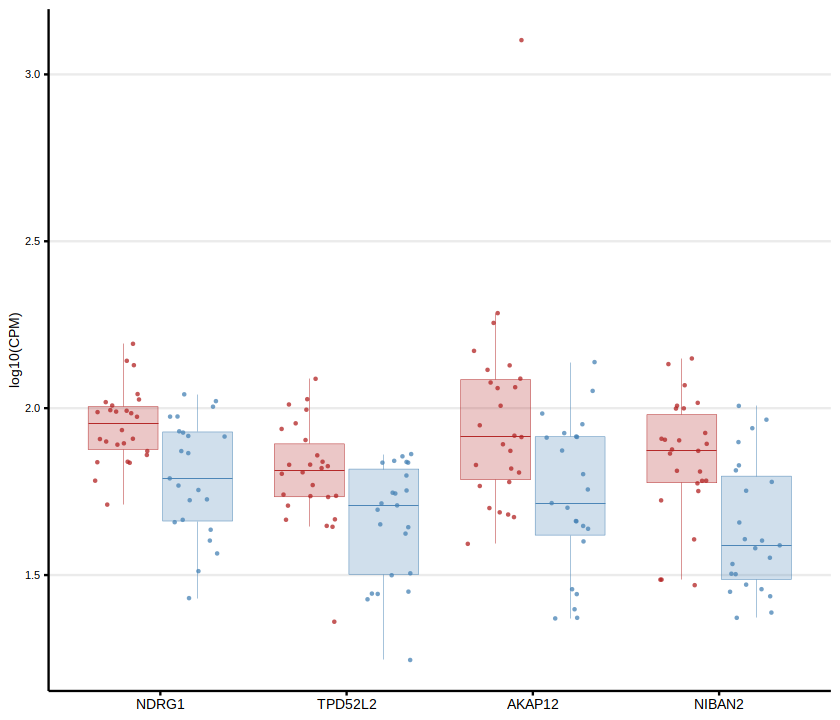

In [52]:

GENEs = c("NDRG1","TPD52L2","AKAP12","NIBAN2")

GENEIDS = gene_key %>% filter(gene_name %in% GENEs) %>% pull(gene_id)

### Normalize counts
CNTS = edgeR::cpm(counts)

### Combine counts with metadata
cnt_df = merge(mdf_daa_pw %>% select(sample_id, date_cgvhd, expGroup), 
        data.frame(t(CNTS[GENEIDS,,drop=FALSE])),
        by.x="sample_id",by.y=0) %>% 
    reshape2::melt(id.vars = c("sample_id","date_cgvhd","expGroup"), variable.name = "gene_id",value.name = "counts")

### Add gene names for plotting
cnt_df = merge(cnt_df, gene_key, by.x="gene_id", by.y="gene_id") %>% 
    mutate(gene_name = factor(gene_name, levels = GENEs))

### Make plot
set.seed(42)
cnt_df %>% 
    ggplot(aes(x=gene_name, y=log10(counts+1), fill = expGroup, color = expGroup))+
    geom_boxplot(outlier.shape = NA, position = position_dodge(width = 0.8), alpha = 0.25, size = 0.1) +
    geom_point(size = 1, alpha = 0.75, stroke=NA,
              position =  position_jitterdodge(jitter.height=0, 
                                                jitter.width=.3, 
                                                dodge.width = 0.8, 
                                                seed=42)
                )+
    theme_cfrna_print()+
    labs(y = "log10(CPM)")+
    theme(
        axis.text.x = element_text(size = 8),
        axis.title.x = element_blank(),
        panel.border = element_blank(),                  # Remove all borders initially
        axis.line = element_line(),                      # Add back the bottom and left lines
        axis.line.x.top = element_blank(),               # Ensure top border is removed
        axis.line.y.right = element_blank(),             # Ensure right border is removed
        panel.grid.minor = element_blank(),             # Remove minor gridlines
        panel.grid.major.x = element_blank()             # Remove major gridlines
        )+
    scale_fill_manual(values = c("success" = "#4682B4", "failure" = "#B22222"))+
    scale_color_manual(values = c("success" = "#4682B4", "failure" = "#B22222"))

### Save
WIDTH = 2.5
HEIGHT= 1.7

## Modeling - CPM TMM

### load data

In [82]:
TIME = c("taper_start")
mdf_mod <- mdf %>% 
    filter(timepoint %in% TIME) %>%
    mutate(timepoint = factor(timepoint, levels=TIME)) %>% 
    mutate(expGroup = ifelse(!is.na(date_cgvhd), 1, 0)) 

### get counts
counts = read.delim("../1_DATA/counts_sQC_gAll_nRaw.tsv")
counts = counts[,mdf_mod$sample_id]


### save outputs to run in python
library(edgeR)

dge = DGEList(counts = counts)
dge = calcNormFactors(dge, method = "TMM")
cpm_values = cpm(dge, log = TRUE)

cpm_values %>% write.csv("./modeling/modeling_counts_cpm_tmm_log.csv", row.names=TRUE, quote=FALSE)
mdf_mod %>% write.csv("./modeling/modeling_metadata.csv",row.names=FALSE,quote=FALSE)

---
# DESEQ2 - pw

In [4]:
suppressMessages(library(DESeq2))

In [55]:
TIME = c("taper_start","taper_end","cGVHD")
mdf_daa_pw <- mdf %>% 
    filter(timepoint %in% TIME) %>%
    filter(!is.na(date_cgvhd)) %>%
    mutate(timepoint = factor(timepoint, levels=TIME))

### get counts
counts = read.delim("../1_DATA/counts_sQC_gAll_nRaw.tsv")
counts_daa = counts[,mdf_daa_pw$sample_id]

counts_vst = read.delim("../1_DATA/counts_sQC_gAll_nVST.tsv")
counts_vst = counts_vst[,mdf_daa_pw$sample_id]

In [56]:
##------------------------------------
## Run DESeq
dds <- DESeqDataSetFromMatrix(counts_daa,
                                colData = mdf_daa_pw,
                                design = ~ Record_ID + timepoint )

# Normalize counts and estimate size factors
dds <- estimateSizeFactors(dds)

# Compute baseMean and filter genes
baseMean_values <- rowMeans(counts(dds, normalized=TRUE))
dds <- dds[baseMean_values > 50, ]

dds <- DESeq(dds)
dds %>% saveRDS("./outputs/DESEQ2_taper_pw.rds")

##------------------------------------
## Get Results
dds = readRDS("./outputs/DESEQ2_taper_pw.rds")
res_start_stop <- results(dds, contrast=c("timepoint","taper_start","taper_end")) %>% data.frame()
res_cgvhd_stop <- results(dds, contrast=c("timepoint","taper_end","cGVHD")) %>% data.frame()

res_start_stop <- merge(res_start_stop,gene_key, by.x=0, by.y="gene_id") %>% column_to_rownames(.,"Row.names")
res_cgvhd_stop <- merge(res_cgvhd_stop,gene_key, by.x=0, by.y="gene_id") %>% column_to_rownames(.,"Row.names")

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

using pre-existing size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) 

In [58]:
res_start_stop %>% arrange(pvalue) %>% head

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene_name,gene_type
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
ENSG00000066294.15,55.71411,0.6908713,0.2304353,2.998115,0.002716554,0.9982947,CD84,protein_coding
ENSG00000145241.11,57.71924,0.5058501,0.1715460,2.948772,0.003190388,0.9982947,CENPC,protein_coding
ENSG00000111801.16,53.02131,-0.5183454,0.1819836,-2.848308,0.004395241,0.9982947,BTN3A3,protein_coding
ENSG00000092020.11,67.60678,0.4723092,0.1725982,2.736466,0.006210296,0.9982947,PPP2R3C,protein_coding
ENSG00000210164.1,111.94052,1.9021462,0.7216972,2.635657,0.008397457,0.9982947,MT-TG,Mt_tRNA
ENSG00000125148.7,110.85679,-0.5334391,0.2081102,-2.563252,0.010369664,0.9982947,MT2A,protein_coding


In [59]:
res_cgvhd_stop %>% arrange(pvalue) %>% head

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene_name,gene_type
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
ENSG00000092020.11,67.60678,-0.7725493,0.1973886,-3.913850,9.083607e-05,0.2631052,PPP2R3C,protein_coding
ENSG00000236876.3,109.82659,-1.6719310,0.4441372,-3.764447,1.669181e-04,0.2631052,TMSB4XP1,processed_pseudogene
ENSG00000201822.1,1089.27726,-1.6012244,0.4357316,-3.674796,2.380400e-04,0.2631052,RNA5SP149,rRNA_pseudogene
ENSG00000252316.1,1162.13695,-1.5545900,0.4264350,-3.645550,2.668209e-04,0.2631052,RNY4,misc_RNA
ENSG00000201098.1,1916.78283,-1.0846006,0.3034823,-3.573851,3.517685e-04,0.2631052,RNY1,misc_RNA
ENSG00000198087.7,163.33569,-0.5074333,0.1427958,-3.553558,3.800571e-04,0.2631052,CD2AP,protein_coding


In [48]:
res_cgvhd_stop %>% 
    filter(padj < 0.1)
    # head

baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene_name,gene_type
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>


---
# DESEQ2 - long

In [44]:
library(DESeq2)

In [50]:
TIME = c("taper_end","wk2_pt","mo1_pt","mo3_pt","mo6_pt")
mdf_daa_long <- mdf %>% 
    filter(timepoint %in% TIME) %>%
    mutate(timepoint = factor(timepoint, levels=TIME))

# gert time of taper end
taper_end1 = read.csv("/workdir/cjl332/moffitt/1_DATA/cohort1_data.csv") %>% select(study_ID, success_date_ID_stop)
taper_end2 = read.csv("/workdir/cjl332/moffitt/1_DATA/cohort2_data.csv") %>% 
    filter(timepoint == "baseline")

taper_end1 %>% head()
taper_end2 %>% head()

# ### get counts
# counts = read.delim("../1_DATA/counts_sQC_gAll_nRaw.tsv")
# counts_daa = counts[,mdf_daa_long$sample_id]

# counts_vst = read.delim("../1_DATA/counts_sQC_gAll_nVST.tsv")
# counts_vst = counts_vst[,mdf_daa_long$sample_id]

,study_ID,date,cohort1_group,success_date_IS_stop,failure_date_during_tape,timepoint,analyte,LV_No,MRN,WBC,RBC,Hgb,PLT,Neutro,Eos,Baso,Mono,lymph
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,2015-10-12,failure_post,2016-05-18,NA,baseline,plasma,06S15087250,674444,5.71,2.96,8.9,190,3.42,0.35,0.05,0.55,1.32
2,1,2015-10-12,failure_post,2016-05-18,NA,baseline,cell,06S15087256,674444,5.71,2.96,8.9,190,3.42,0.35,0.05,0.55,1.32
3,1,2016-05-18,failure_post,2016-05-18,NA,success,plasma,06S16032593,674444,6.71,3.36,11.0,168,3.75,0.26,0.04,0.73,1.90
4,1,2016-05-18,failure_post,2016-05-18,NA,success,cell,06S16032598,674444,6.71,3.36,11.0,168,3.75,0.26,0.04,0.73,1.90
5,1,2016-11-16,failure_post,2016-05-18,NA,failure,plasma,06S16082802,674444,7.70,3.77,12.0,239,4.38,0.71,0.07,0.87,1.63
6,1,2016-11-16,failure_post,2016-05-18,NA,failure,cell,06S16082807,674444,7.70,3.77,12.0,239,4.38,0.71,0.07,0.87,1.63


,study_ID,date,success_vs_failure,date_of_failure,timepoint,LV_No,analyte,MRN,WBC,RBC,Hgb,PLT,Neutro,Eos,Baso,Mono,lymph
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,2016-05-18,failure,2016-11-16,baseline,06S16032594,plasma,674444,6.71,3.36,11.0,168,3.75,0.26,0.04,0.73,1.90
2,1,2016-05-18,failure,2016-11-16,baseline,06S16032598,cell,674444,6.71,3.36,11.0,168,3.75,0.26,0.04,0.73,1.90
3,1,2016-06-15,failure,2016-11-16,mo1,06S16041207,cell,674444,5.69,3.07,10.3,167,3.33,0.26,0.03,0.65,1.41
4,1,2016-08-17,failure,2016-11-16,mo3,06S16058935,cell,674444,6.57,3.34,11.1,205,3.79,0.46,0.05,0.74,1.50
5,1,2016-11-16,failure,2016-11-16,failure,06S16082807,cell,674444,7.70,3.77,12.0,239,4.38,0.71,0.07,0.87,1.63
6,1,2016-11-16,failure,2016-11-16,failure,06S16082807,cell,674444,7.70,3.77,12.0,239,4.38,0.71,0.07,0.87,1.63


In [ ]:
##------------------------------------
## Run DESeq
dds <- DESeqDataSetFromMatrix(counts_daa,
                                colData = mdf_daa_long,
                                design = ~ Record_ID + timepoint )
dds <- DESeq(dds)
dds %>% saveRDS("./outputs/DESEQ2_taper_long.rds")

##------------------------------------
## Get Results
dds = readRDS("./outputs/DESEQ2_taper_pw.rds")
res_start_stop <- results(dds, contrast=c("timepoint","taper_start","taper_end")) %>% data.frame()
res_cgvhd_stop <- results(dds, contrast=c("timepoint","taper_end","cGVHD")) %>% data.frame()

res_start_stop <- merge(res_start_stop,gene_key, by.x=0, by.y="gene_id") %>% column_to_rownames(.,"Row.names")
res_cgvhd_stop <- merge(res_cgvhd_stop,gene_key, by.x=0, by.y="gene_id") %>% column_to_rownames(.,"Row.names")

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 81 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing



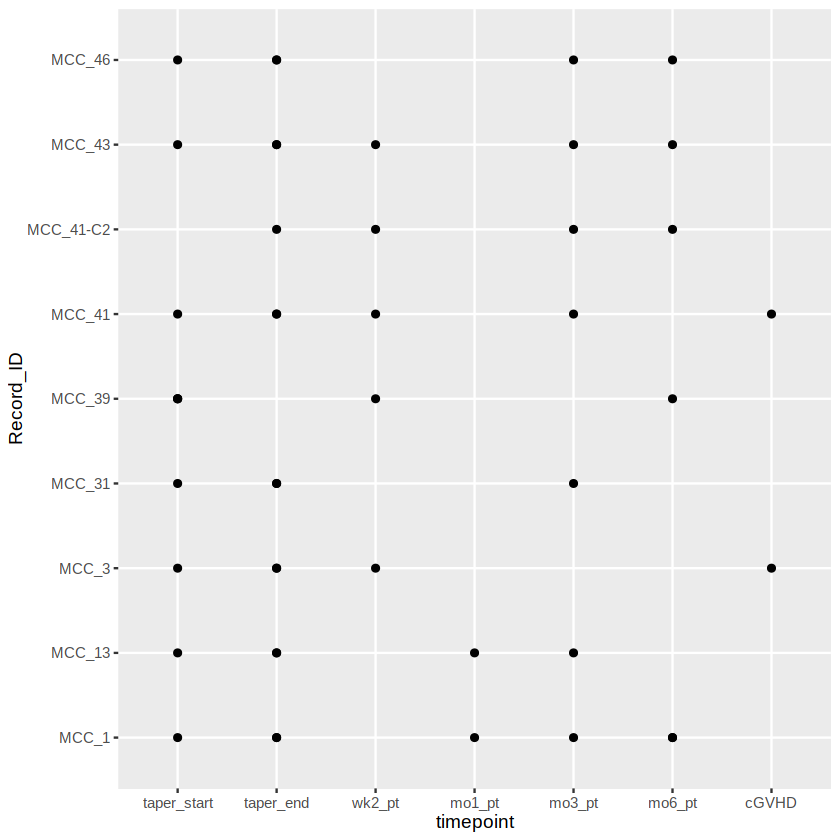

In [25]:
later_ids = mdf %>% filter(timepoint %in% c("wk2_pt","mo1_pt","mo3_pt","mo6_pt")) %>% pull(Record_ID) %>% unique()


mdf %>% 
    mutate(timepoint = factor(timepoint, levels = EVENTS)) %>%
    filter(Record_ID %in% later_ids) %>% 
    ggplot(aes(x=timepoint,y=Record_ID))+
    geom_point()